In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv('Mall_Customers.csv')


df.columns = [col.strip().lower().replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 5)


,customerid,gender,age,annual_income_k$,spending_score_1-100
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 customerid              0
gender                  0
age                     0
annual_income_k$        0
spending_score_1-100    0
dtype: int64


In [4]:
X = df.drop(columns=['customerid'])

In [5]:
if 'gender' in X.columns:
    le = LabelEncoder()
    X['gender'] = le.fit_transform(X['gender'])

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Data Shape:", X_scaled.shape)


Scaled Data Shape: (200, 4)


In [7]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

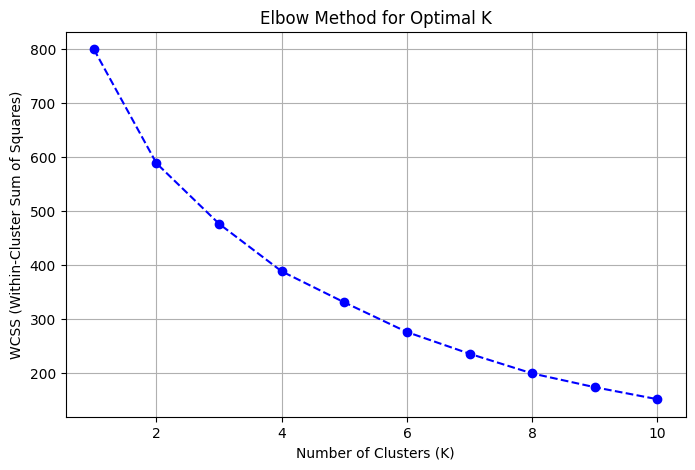

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [9]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [10]:
print(f"\nAssigned {optimal_k} clusters to the dataset.")


Assigned 5 clusters to the dataset.


In [11]:
cluster_profile = df.groupby('cluster').agg({
    'age': 'mean',
    'annual_income_k$': 'mean',
    'spending_score_1-100': 'mean',
    'customerid': 'count'
}).rename(columns={'customerid': 'customer_count'})

In [12]:
cluster_names = {
    0: 'Sensible Shoppers (Moderate Income, Low Spending)',
    1: 'High Earners, Low Spenders (Target for Premium Retention)',
    2: 'Young High Spenders (High Income, High Spending)',
    3: 'Careful Saver / Budget Buyers (Low Income, Low Spending)',
    4: 'Impulse Buyers (Low Income, High Spending)'
}

In [13]:
df['segment_name'] = df['cluster'].map(cluster_names)

print("=== Cluster Summary ===")
print(cluster_profile)

=== Cluster Summary ===
               age  annual_income_k$  spending_score_1-100  customer_count
cluster                                                                   
0        32.692308         86.538462             82.128205              39
1        36.482759         89.517241             18.000000              29
2        49.813953         49.232558             40.069767              43
3        24.907407         39.722222             61.203704              54
4        55.714286         53.685714             36.771429              35


In [14]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

df['pca1'] = pca_features[:, 0]
df['pca2'] = pca_features[:, 1]

var_explained = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: Component 1 = {var_explained[0]:.2%}, Component 2 = {var_explained[1]:.2%}")
print(f"Total Variance Explained = {sum(var_explained):.2%}")

Explained Variance Ratio: Component 1 = 33.69%, Component 2 = 26.23%
Total Variance Explained = 59.92%


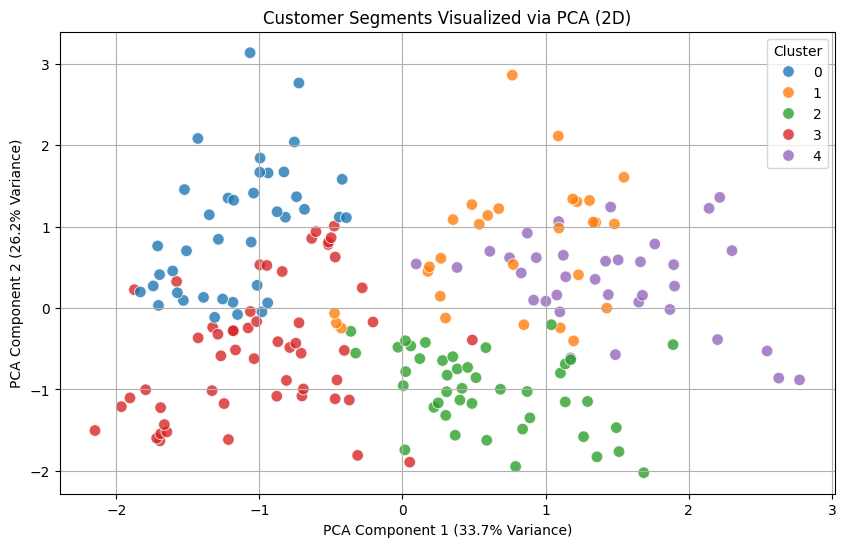

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    palette='tab10',
    data=df,
    s=70, alpha=0.8
)
plt.title('Customer Segments Visualized via PCA (2D)')
plt.xlabel(f'PCA Component 1 ({var_explained[0]:.1%} Variance)')
plt.ylabel(f'PCA Component 2 ({var_explained[1]:.1%} Variance)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()